In [ ]:
!pip install pandas
!pip install seaborn


import pandas as pd
import seaborn as srn
import statistics as sts

In [157]:
#Importar dados
dataset = pd.read_csv("tempo.csv", sep=";")
#vizualizar
dataset.head()

,Aparencia,Temperatura,Umidade,Vento,Jogar
0,sol,85,85.0,FALSO,nao
1,sol,80,90.0,VERDADEIRO,nao
2,nublado,83,86.0,FALSO,sim
3,chuva,70,NaN,FALSO,sim
4,chuva,68,80.0,FALSO,sim


Explorar dados Categoricos


In [158]:
#Aparencia
agrupado = dataset.groupby(['Aparencia']).size()
agrupado

Aparencia
chuva      5
menos      1
nublado    3
sol        5
dtype: int64

<Axes: xlabel='Vento'>

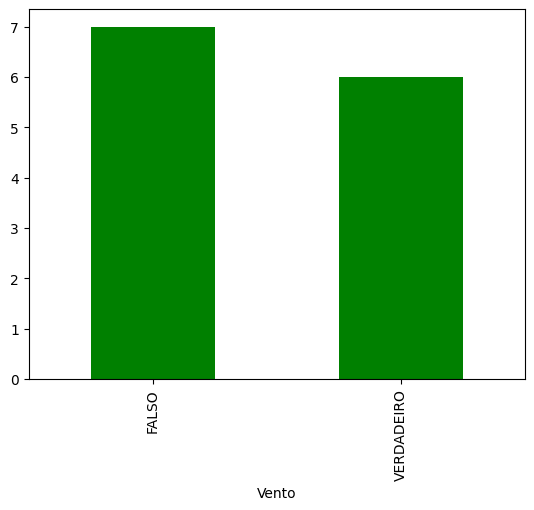

In [172]:
agrupado.plot.bar(color = 'green')

In [196]:
#Vento
agrupado = dataset.groupby(['Vento']).size()
agrupado


Vento
FALSO         7
VERDADEIRO    6
dtype: int64

<Axes: xlabel='Vento'>

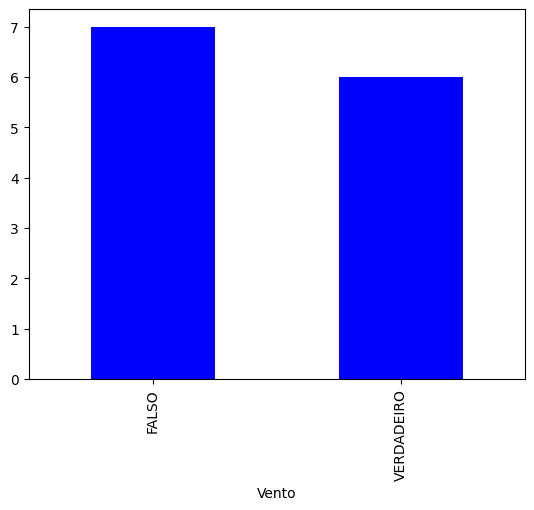

In [174]:
agrupado.plot.bar(color ='blue')

Colunas Numéricas

In [162]:
#Temperatura
dataset['Temperatura'].describe()

count      14.000000
mean      155.571429
std       306.433759
min        64.000000
25%        69.250000
50%        73.500000
75%        80.750000
max      1220.000000
Name: Temperatura, dtype: float64

Text(0.5, 1.0, 'Temperatura')

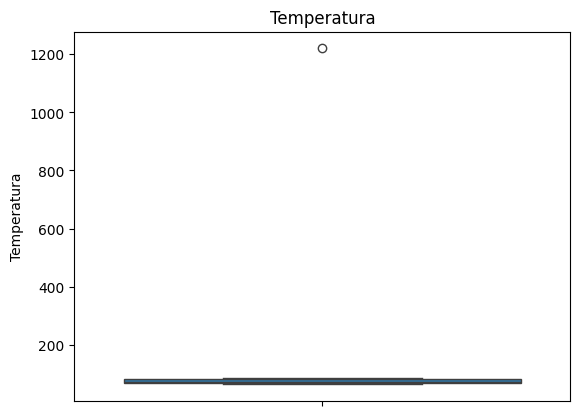

In [163]:
srn.boxplot(dataset['Temperatura']).set_title('Temperatura')

Text(0.5, 1.0, 'Temperatura')

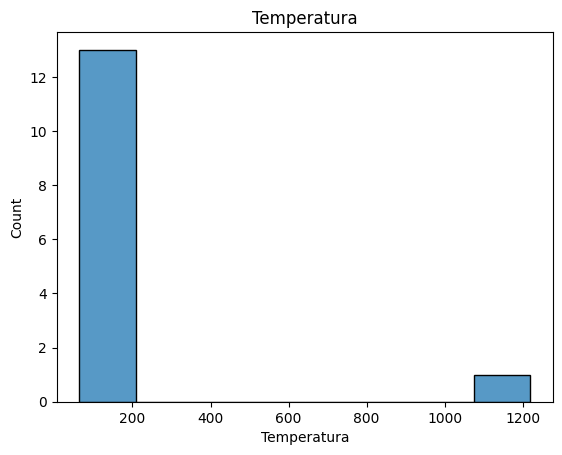

In [164]:
srn.histplot(dataset['Temperatura']).set_title('Temperatura')

In [165]:
#Umidade
dataset['Umidade'].describe()

count     13.000000
mean      89.769231
std       34.540203
min       65.000000
25%       70.000000
50%       85.000000
75%       90.000000
max      200.000000
Name: Umidade, dtype: float64

Text(0.5, 1.0, 'Umidade')

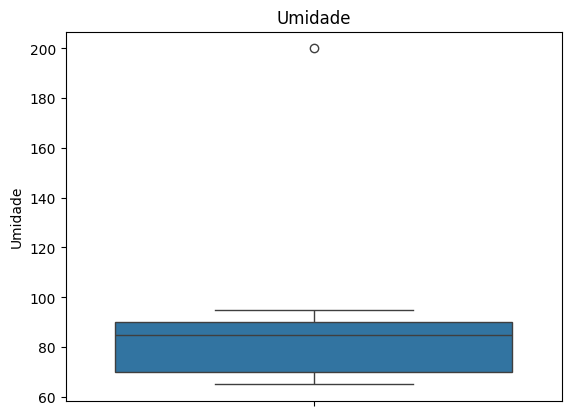

In [166]:
srn.boxplot(dataset['Umidade']).set_title('Umidade')

Text(0.5, 1.0, 'Umidade')

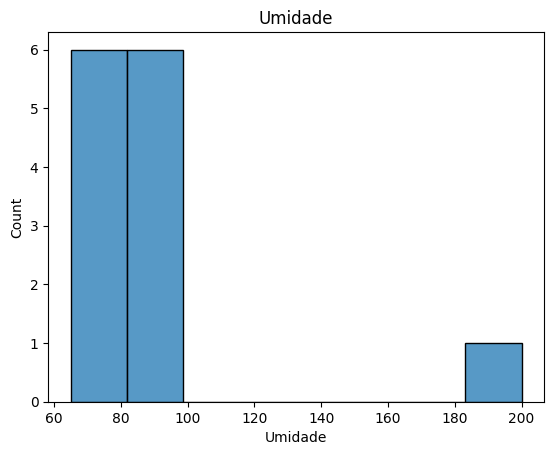

In [167]:
srn.histplot(dataset['Umidade']).set_title('Umidade')

Contando Valores NAN

In [189]:
dataset.isnull().sum()

Aparencia      0
Temperatura    0
Umidade        0
Vento          1
Jogar          0
dtype: int64

In [169]:
#Umidade
dataset['Umidade'].describe()

count     13.000000
mean      89.769231
std       34.540203
min       65.000000
25%       70.000000
50%       85.000000
75%       90.000000
max      200.000000
Name: Umidade, dtype: float64

In [170]:
mediana = sts.median(dataset['Umidade'])
mediana

85.5

In [175]:
#substituir NAN por mediana
dataset['Umidade'] = dataset['Umidade'].fillna(mediana)


In [176]:
#Verificamos se NAN não existem mais
dataset['Umidade'].isnull().sum()
dataset.isnull().sum()

Aparencia      0
Temperatura    0
Umidade        0
Vento          1
Jogar          0
dtype: int64

Falta de padronização e NAs

In [177]:
agrupado = dataset.groupby(['Aparencia']).size()
agrupado

Aparencia
chuva      5
menos      1
nublado    3
sol        5
dtype: int64

In [181]:
#Padronizar de acordo com o dominio
dataset.loc[dataset['Aparencia'].isin(['menos']), 'Aparencia'] = "sol"


In [182]:
#Vizualiza mudanças
agrupado = dataset.groupby(['Aparencia']).size()
agrupado


Aparencia
chuva      5
nublado    3
sol        6
dtype: int64

In [197]:
#Total de NAs
dataset['Vento'].isnull().sum()

np.int64(1)

In [198]:
#Preenche NAs com FALSO(Maioria)
dataset['Vento'] = dataset['Vento'].fillna("FALSO")

In [199]:
#Verificamos novamente
dataset.isnull().sum()

Aparencia      0
Temperatura    0
Umidade        0
Vento          0
Jogar          0
dtype: int64

Dados fora de dominio

In [206]:
#Buscar Mediana
medianaT = sts.median(dataset['Temperatura'])
medianaU = sts.median(dataset['Umidade'])

In [208]:
#Temperatura
dataset.loc[(dataset['Temperatura'] < 50 ) | (dataset['Temperatura'] > 90), 'Temperatura'] = round(medianaT)
dataset.loc[(dataset['Temperatura'] < 50 ) | (dataset['Temperatura'] > 90)]

,Aparencia,Temperatura,Umidade,Vento,Jogar


In [211]:
#Umidade
dataset.loc[(dataset['Umidade'] < 60 ) | (dataset['Umidade'] > 96), 'Umidade'] = round(medianaU)
dataset.loc[(dataset['Umidade'] < 60 ) | (dataset['Umidade'] > 96)]

,Aparencia,Temperatura,Umidade,Vento,Jogar
